In [26]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tiktoken
from sklearn.model_selection import train_test_split

# LOAD DATA

## SAFRAN PROJECT DATASET

**The ASRS data loaded below are the final clean dataset used to feed the model => They have been splited in 10 fold already with the final laebls**. 

We import these data in this notebook for (re)-exploration 

In [27]:
train_data = pd.read_parquet(
    "../data/03_final/final_safran_asrs_14label_fit_10fold_seed_4294967295.parquet"
)
test_data = pd.read_parquet("../data/03_final/final_safran_asrs_14label_test.parquet")

In [28]:
train_data.head()

,acn,narrative,anomaly,fold
0,1299097,The flight came over descending to FL240 flyin...,Deviation/Discrepancy - Procedural ; Deviation...,3.0
1,1299098,I was sequencing multiple arrivals to ZZZ; 2 r...,Conflict ; Deviation/Discrepancy - Procedural ...,2.0
2,1299106,An aircraft entered New York's non-radar airsp...,Airspace Violation ; Deviation/Discrepancy - P...,7.0
3,1299250,We were cruising at FL360; in cirrus type clou...,Deviation/Discrepancy - Procedural ; Flight De...,4.0
4,1299290,Bird strike at approximately 300-400 AGL durin...,Inflight Event/Encounter ; Aircraft Equipment,0.0


In [29]:
test_data.head()

,acn,narrative,anomaly
13,1299665,Weather scattered about 4;500 feet could not s...,Deviation/Discrepancy - Procedural ; Deviation...
33,1300042,As we approached Runway 8 in DEN for takeoff; ...,Inflight Event/Encounter ; ATC Issue
49,1300383,Upon being seated in the hotel van; the van dr...,Airspace Violation ; Deviation/Discrepancy - P...
70,1300774,Cleared to taxi into position and hold Runway ...,Conflict ; Ground Incursion ; ATC Issue ; Devi...
72,1300807,During a training flight; I was making routine...,Conflict ; Deviation/Discrepancy - Procedural


In [30]:
(train_data.shape, test_data.shape)

((89724, 4), (10023, 3))

## 1988 - 2025 ASRS's DATA (some reports may be missing due to processing)

In [31]:
asrs = pd.read_parquet("../data/01_primary/asrs_data_primary.parquet")

Let's merge `asrs` dataframe with `safran` dataframes to get raw unprocessed labels.

In [32]:
train_acn = train_data.acn.tolist()
test_acn = test_data.acn.tolist()
full_acn = train_acn + test_acn

In [33]:
train_data = asrs.loc[asrs.acn.isin(train_acn)][["acn", "narrative", "anomaly"]]
test_data = asrs.loc[asrs.acn.isin(test_acn)][["acn", "narrative", "anomaly"]]
full_data = asrs.loc[asrs.acn.isin(full_acn)][["acn", "narrative", "anomaly"]]

In [34]:
(train_data.shape, test_data.shape)

((89724, 3), (10023, 3))

In [35]:
train_data.head()

,acn,narrative,anomaly
0,1299097,The flight came over descending to FL240 flyin...,Deviation - Altitude Crossing Restriction Not ...
1,1299098,I was sequencing multiple arrivals to ZZZ; 2 r...,Conflict Airborne Conflict; Deviation - Speed ...
2,1299106,An aircraft entered New York's non-radar airsp...,Airspace Violation All Types; Deviation / Disc...
3,1299250,We were cruising at FL360; in cirrus type clou...,Deviation - Altitude Excursion From Assigned A...
4,1299290,Bird strike at approximately 300-400 AGL durin...,Aircraft Equipment Problem Less Severe; Inflig...


In [36]:
test_data.head()

,acn,narrative,anomaly
13,1299665,Weather scattered about 4;500 feet could not s...,Deviation - Altitude Excursion From Assigned A...
33,1300042,As we approached Runway 8 in DEN for takeoff; ...,ATC Issue All Types; Inflight Event / Encounte...
49,1300383,Upon being seated in the hotel van; the van dr...,Airspace Violation All Types; Deviation / Disc...
70,1300774,Cleared to taxi into position and hold Runway ...,ATC Issue All Types; Conflict Ground Conflict;...
72,1300807,During a training flight; I was making routine...,Conflict Airborne Conflict; Deviation / Discre...


Let load the taxonomy extracted from the taxonomy pdf files

In [37]:
with open("../data/01_primary/taxonomy.json", "r") as f:
    taxonomy = json.load(f)
print(taxonomy)

{'Aircraft Equipment': ['Critical', 'Less Severe'], 'Airspace Violation': ['All Types'], 'ATC Issues': ['All Types'], 'Flight Deck/Cabin/Aircraft Event': ['Illness / Injury', 'Passenger Electronic Device', 'Passenger Misconduct', 'Smoke / Fire / Fumes / Odor', 'Other / Unknown'], 'Conflict': ['NMAC', 'Airborne Conflict', 'Ground Conflict, Critical', 'Ground Conflict, Less Severe'], 'Deviation - Altitude': ['Crossing Restriction Not Met', 'Excursion from Assigned Altitude', 'Overshoot', 'Undershoot'], 'Deviation - Speed': ['All Types'], 'Deviation - Track/Heading': ['All Types'], 'Deviation / Discrepancy - Procedural': ['Clearance', 'FAR', 'Hazardous Material Violation', 'Landing without Clearance', 'Maintenance', 'MEL / CDL', 'Published Material/Policy', 'Security', 'Unauthorized Flight Operations (UAS)', 'Weight and Balance', 'Other / Unknown'], 'Ground Excursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Incursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Event/Encounter': ['Aircraft', 

# FUNC

In [38]:
def get_cat(taxonomy, exclude, include):
    return [cat for cat in taxonomy.keys() if cat not in exclude] + include


def re_pattern(categories):
    escaped_categories = [
        re.escape(term.strip().replace(" / ", "/")) for term in categories
    ]
    return re.compile(r"^(" + "|".join(escaped_categories) + r")")

In [39]:
def get_categories(
    text: "str", pattern: "re.Pattern", mode: "str" = "taxonomy", exclude: "list" = None
):
    if mode not in ["all", "unknown", "taxonomy", "other"]:
        raise ValueError('`mode` value must be in ["all", "unknown", "taxonomy"]')
    if text is not None:
        split = text.split(";")
        anomalies = []
        for a in split:
            label = a.strip().replace(" / ", "/")
            out = pattern.findall(label)
            if out == [] and mode != "taxonomy":
                if mode == "all":
                    out = [label]
                elif mode == "unknown":
                    out = ["Unknown"]
                elif mode == "other":
                    out = ["Other"]
            if isinstance(exclude, list) and out != []:
                out = [cat for cat in out if cat not in exclude]
            anomalies.extend(out)
        return " ; ".join(set(anomalies))

In [40]:
def one_hot(mapper, text: "str | None" = None):
    if text is None:
        return text
    num_labels = [0] * len(mapper)
    labels = [label.strip().replace(" / ", "/") for label in text.split(";")]
    for label in labels:
        num_labels[mapper[label]] = 1
    return num_labels

In [41]:
def get_onehot_mapping(categories, n):
    one_hot_mapping = dict(zip(sorted(categories), range(0, n)))
    one_hot_mapping = {
        k.strip().replace(" / ", "/"): v for (k, v) in one_hot_mapping.items()
    }
    return one_hot_mapping

In [42]:
def get_occurences(serie: "pd.Series"):
    occurences = []
    none_counter = 0
    for item in serie.to_list():
        if item is not None:
            occurences.extend([term.strip() for term in item.split(";")])
        else:
            none_counter += 1
    counter = Counter(occurences)
    return counter, none_counter

In [43]:
def get_cooc_mat(series, mapping):
    one_hot_anomalies = series.apply(lambda text: one_hot(mapping, text))
    labels = np.array([l for l in one_hot_anomalies.values])
    cooc = ((labels.T @ labels) / labels.shape[0]) * 100
    mask = np.triu(np.ones_like(cooc, dtype=bool), k=1)
    return cooc, mask, labels

In [44]:
def plot_cooc(cooc, mask, labels, **kwargs):
    plt.figure(figsize=kwargs["figsize"])

    ax = sns.heatmap(
        cooc,
        yticklabels=labels,
        xticklabels=labels,
        annot=kwargs["annot"],
        cmap=kwargs["cmap"],
        mask=mask,
        annot_kws={"size": kwargs["annot_kws"]},
    )

    ax.set_title(kwargs["title"], fontsize=10)

    ax.tick_params(axis="x", labelsize=kwargs["x_labelsize"])
    ax.tick_params(axis="y", labelsize=kwargs["y_labelsize"])

    plt.tight_layout()
    plt.show()

In [45]:
taxonomy_categories = get_cat(taxonomy, ["ATC Issues"], ["ATC Issue", "Unknown"])
pattern = re_pattern(taxonomy_categories)

print("Taxonomy : ", taxonomy)
print("Taxonomy categories : ", taxonomy_categories)
print("Re Pattern : ", pattern)

Taxonomy :  {'Aircraft Equipment': ['Critical', 'Less Severe'], 'Airspace Violation': ['All Types'], 'ATC Issues': ['All Types'], 'Flight Deck/Cabin/Aircraft Event': ['Illness / Injury', 'Passenger Electronic Device', 'Passenger Misconduct', 'Smoke / Fire / Fumes / Odor', 'Other / Unknown'], 'Conflict': ['NMAC', 'Airborne Conflict', 'Ground Conflict, Critical', 'Ground Conflict, Less Severe'], 'Deviation - Altitude': ['Crossing Restriction Not Met', 'Excursion from Assigned Altitude', 'Overshoot', 'Undershoot'], 'Deviation - Speed': ['All Types'], 'Deviation - Track/Heading': ['All Types'], 'Deviation / Discrepancy - Procedural': ['Clearance', 'FAR', 'Hazardous Material Violation', 'Landing without Clearance', 'Maintenance', 'MEL / CDL', 'Published Material/Policy', 'Security', 'Unauthorized Flight Operations (UAS)', 'Weight and Balance', 'Other / Unknown'], 'Ground Excursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Incursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Event/Encounter': [

In [46]:
train_data.loc[:, "anomaly"] = train_data.anomaly.apply(
    lambda x: get_categories(x, pattern, mode="other")
)
test_data.loc[:, "anomaly"] = test_data.anomaly.apply(
    lambda x: get_categories(x, pattern, mode="other")
)

In [47]:
taxonomy_categories

['Aircraft Equipment',
 'Airspace Violation',
 'Flight Deck/Cabin/Aircraft Event',
 'Conflict',
 'Deviation - Altitude',
 'Deviation - Speed',
 'Deviation - Track/Heading',
 'Deviation / Discrepancy - Procedural',
 'Ground Excursion',
 'Ground Incursion',
 'Ground Event/Encounter',
 'Inflight Event/Encounter',
 'No Specific Anomaly Occurred',
 'Other',
 'ATC Issue',
 'Unknown']

In [48]:
mapping = get_onehot_mapping(taxonomy_categories, 15)

In [49]:
mapping

{'ATC Issue': 0,
 'Aircraft Equipment': 1,
 'Airspace Violation': 2,
 'Conflict': 3,
 'Deviation - Altitude': 4,
 'Deviation - Speed': 5,
 'Deviation - Track/Heading': 6,
 'Deviation/Discrepancy - Procedural': 7,
 'Flight Deck/Cabin/Aircraft Event': 8,
 'Ground Event/Encounter': 9,
 'Ground Excursion': 10,
 'Ground Incursion': 11,
 'Inflight Event/Encounter': 12,
 'No Specific Anomaly Occurred': 13,
 'Other': 14}

## Removing NSAO and Other

# Removing obs (Only from train)

In [50]:
train_labels = np.array(
    [l for l in train_data.anomaly.apply(lambda text: one_hot(mapping, text)).values]
)

In [51]:
train_data = train_data.loc[
    ~(
        ((train_labels[:, -1] == 1) & (np.sum(train_labels, axis=1) == 1))
        | (train_labels[:, -2] == 1)
    )
]

## Getting final categories

In [54]:
taxonomy_categories = get_cat(
    taxonomy, ["ATC Issues", "No Specific Anomaly Occurred", "Other"], ["ATC Issue"]
)
pattern = re_pattern(taxonomy_categories)

In [55]:
mapping = get_onehot_mapping(taxonomy_categories, 13)
mapping

{'ATC Issue': 0,
 'Aircraft Equipment': 1,
 'Airspace Violation': 2,
 'Conflict': 3,
 'Deviation - Altitude': 4,
 'Deviation - Speed': 5,
 'Deviation - Track/Heading': 6,
 'Deviation/Discrepancy - Procedural': 7,
 'Flight Deck/Cabin/Aircraft Event': 8,
 'Ground Event/Encounter': 9,
 'Ground Excursion': 10,
 'Ground Incursion': 11,
 'Inflight Event/Encounter': 12}

In [56]:
train_data.loc[:, "anomaly"] = train_data.anomaly.apply(
    lambda x: get_categories(
        x, pattern, mode="other", exclude=["Other", "No Specific Anomaly Occurred"]
    )
)
test_data.loc[:, "anomaly"] = test_data.anomaly.apply(
    lambda x: get_categories(
        x, pattern, mode="other", exclude=["Other", "No Specific Anomaly Occurred"]
    )
)

## CREATE FOLD

In [57]:
np.random.seed(4294967295)
train_data.loc[:, "fold"] = np.random.randint(low=0, high=10, size=len(train_data))

In [58]:
counters = zip(
    [
        get_occurences(train_data.anomaly.loc[train_data.fold == f])[0]
        for f in range(10)
    ],
    [f"fold-{i}" for i in range(10)],
)

In [59]:
data = [
    pd.DataFrame(
        {
            "anomaly": counter.keys(),
            "count": counter.values(),
            "fold": [fold] * len(counter),
        }
    )
    for (counter, fold) in counters
]
data = pd.concat(data).reset_index()

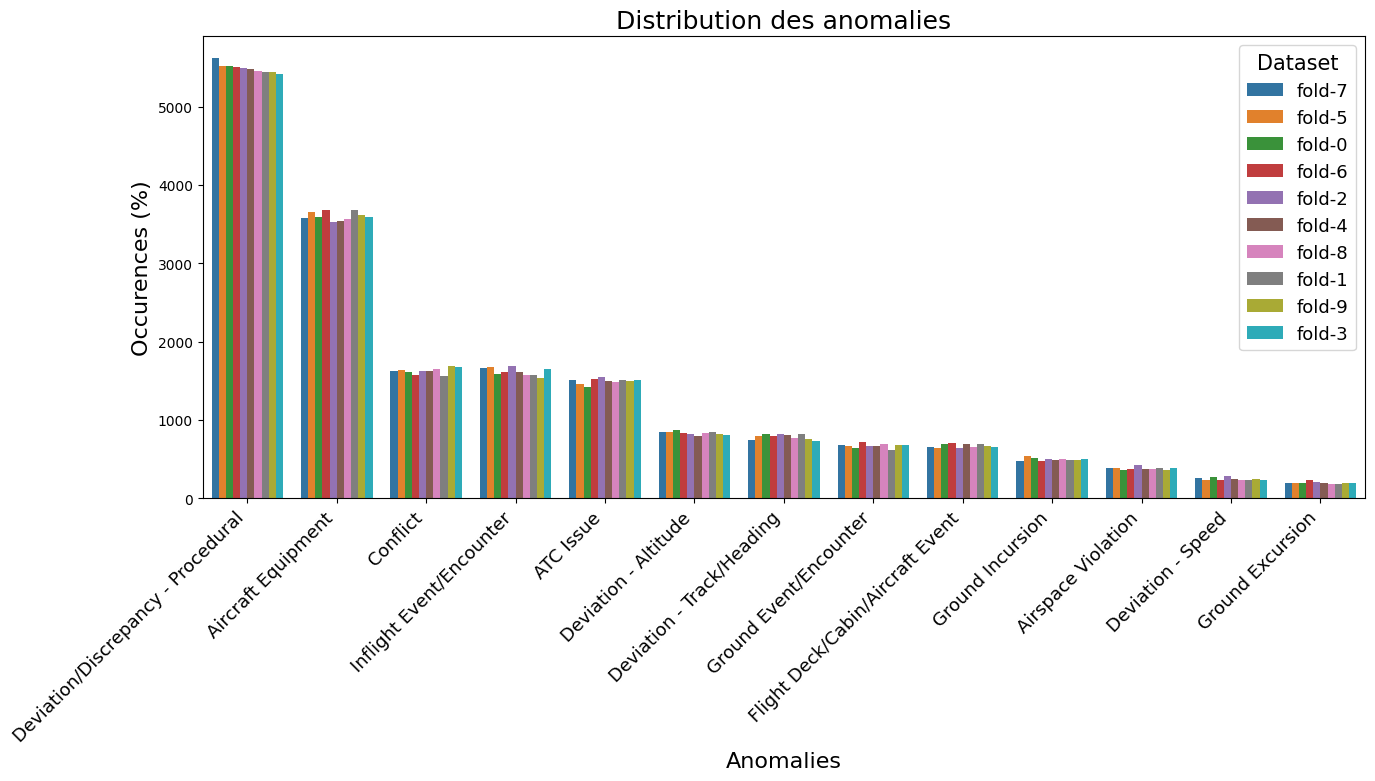

In [60]:
plt.figure(figsize=(15, 6))
sns.barplot(
    data=data.sort_values(by=["count", "fold"], ascending=False),
    hue="fold",
    x="anomaly",
    y="count",
)
plt.xticks(rotation=45, ha="right", fontsize=13)  # or try 90 for vertical
plt.xlabel("Anomalies", fontsize=16)
plt.ylabel("Occurences (%)", fontsize=16)
plt.title("Distribution des anomalies", fontsize=18)
plt.legend(title="Dataset", title_fontsize=15, fontsize=13)
plt.show()

# EXPORT des données

In [ ]:
# train_data.to_parquet("../data/03_final/final_safran_asrs_14label_fit_10fold_seed_4294967295_v3.parquet", index=False)
# test_data.to_parquet("../data/03_final/final_safran_asrs_14label_test_v3.parquet", index=False)

In [68]:
with open("../data/01_primary/one_hot_mapping_v3.json", "w") as f:
    json.dump(mapping, f, indent=4)